In [38]:
# Ensure all required packages are installed in the notebook kernel
%pip install nltk scikit-learn matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Sentiment Analysis using NLP Pipeline & ML Models
**Objective:** Build an end-to-end Sentiment Analysis system using NLP preprocessing, feature engineering, and multiple ML models. Compare their performance using evaluation metrics.

## 1. Data Understanding
- Load the dataset (Twitter Sentiment Dataset)
- Explore number of samples, class distribution, and sample texts.

In [39]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Load Dataset
Dataset: Twitter Sentiment Dataset (Kaggle)

In [40]:
# Load Twitter Sentiment Training Dataset with correct columns
df = pd.read_csv('twitter_sentiment_dataset/twitter_training.csv', header=None, names=['id','topic','sentiment','text'])
df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Shape: (74682, 4)
Columns: Index(['id', 'topic', 'sentiment', 'text'], dtype='object')
Class distribution:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution'}, xlabel='sentiment'>

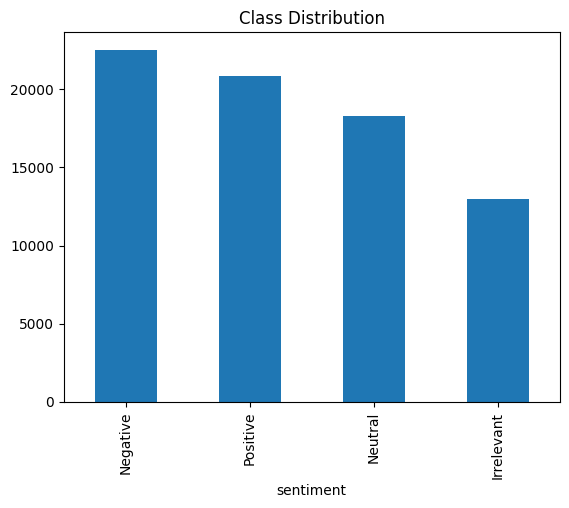

In [41]:
# Dataset info
print('Shape:', df.shape)
print('Columns:', df.columns)
print('Class distribution:')
print(df['sentiment'].value_counts())
df['sentiment'].value_counts().plot(kind='bar', title='Class Distribution')

In [42]:
# Show sample texts
df.sample(5)

,id,topic,sentiment,text
40618,1370,Battlefield,Irrelevant,A final ban proposed for Battlefield Marvel 4 ...
41272,1482,Battlefield,Neutral,Google Ok Battlefield V’s Nazi story “The Last...
20989,12793,WorldOfCraft,Positive,"ahh, these are SO awesome! I bought absolutely..."
7233,9243,Overwatch,Neutral,Overwatch Fans are Split Over Hero Pool Change...
31754,7451,LeagueOfLegends,Irrelevant,oh shoot me I was a victim of this virus and m...


## 2. NLP Preprocessing
- Lowercasing, removing punctuation, stopwords, tokenization, stemming/lemmatization, handling special characters/URLs.
- Reusable functions provided.

In [43]:
# Preprocessing functions
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text, use_stem=False, use_lemma=True):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    # Stemming or Lemmatization
    if use_stem:
        tokens = [stemmer.stem(w) for w in tokens]
    elif use_lemma:
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

In [44]:
# Apply preprocessing (handle missing values)
df['clean_text'] = df['text'].fillna('').apply(lambda x: clean_text(x, use_stem=False, use_lemma=True))
df[['text', 'clean_text']].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


## 3. Feature Engineering
- Bag of Words (BoW) and TF-IDF vectorization.

In [45]:
# Split data
X = df['clean_text']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# Bag of Words
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

## 4. Model Building
- Logistic Regression, Naive Bayes, Decision Tree.

In [47]:
# Helper function for training and evaluation
def train_and_evaluate(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    print(classification_report(y_te, y_pred))
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

In [48]:
# Logistic Regression (BoW)
lr_bow = LogisticRegression(max_iter=200)
results_lr_bow = train_and_evaluate(lr_bow, X_train_bow, X_test_bow, y_train, y_test)

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

  Irrelevant       0.86      0.73      0.79      2598
    Negative       0.84      0.84      0.84      4509
     Neutral       0.85      0.77      0.80      3664
    Positive       0.74      0.87      0.80      4166

    accuracy                           0.81     14937
   macro avg       0.82      0.80      0.81     14937
weighted avg       0.82      0.81      0.81     14937



In [49]:
# Logistic Regression (TF-IDF)
lr_tfidf = LogisticRegression(max_iter=200)
results_lr_tfidf = train_and_evaluate(lr_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test)

              precision    recall  f1-score   support

  Irrelevant       0.82      0.66      0.73      2598
    Negative       0.80      0.83      0.81      4509
     Neutral       0.72      0.75      0.74      3664
    Positive       0.77      0.80      0.79      4166

    accuracy                           0.77     14937
   macro avg       0.78      0.76      0.77     14937
weighted avg       0.78      0.77      0.77     14937



In [50]:
# Naive Bayes (BoW)
nb_bow = MultinomialNB()
results_nb_bow = train_and_evaluate(nb_bow, X_train_bow, X_test_bow, y_train, y_test)

              precision    recall  f1-score   support

  Irrelevant       0.82      0.60      0.69      2598
    Negative       0.69      0.85      0.76      4509
     Neutral       0.80      0.61      0.69      3664
    Positive       0.70      0.79      0.74      4166

    accuracy                           0.73     14937
   macro avg       0.75      0.71      0.72     14937
weighted avg       0.74      0.73      0.73     14937



In [51]:
# Naive Bayes (TF-IDF)
nb_tfidf = MultinomialNB()
results_nb_tfidf = train_and_evaluate(nb_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test)

              precision    recall  f1-score   support

  Irrelevant       0.95      0.40      0.56      2598
    Negative       0.63      0.90      0.74      4509
     Neutral       0.84      0.58      0.68      3664
    Positive       0.69      0.80      0.74      4166

    accuracy                           0.71     14937
   macro avg       0.78      0.67      0.68     14937
weighted avg       0.75      0.71      0.70     14937



In [52]:
# Decision Tree (BoW)
dt_bow = DecisionTreeClassifier(random_state=42)
results_dt_bow = train_and_evaluate(dt_bow, X_train_bow, X_test_bow, y_train, y_test)

              precision    recall  f1-score   support

  Irrelevant       0.83      0.75      0.78      2598
    Negative       0.84      0.83      0.83      4509
     Neutral       0.74      0.82      0.78      3664
    Positive       0.82      0.81      0.82      4166

    accuracy                           0.81     14937
   macro avg       0.81      0.80      0.80     14937
weighted avg       0.81      0.81      0.81     14937



In [53]:
# Decision Tree (TF-IDF)
dt_tfidf = DecisionTreeClassifier(random_state=42)
results_dt_tfidf = train_and_evaluate(dt_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test)

              precision    recall  f1-score   support

  Irrelevant       0.79      0.69      0.74      2598
    Negative       0.83      0.81      0.82      4509
     Neutral       0.71      0.79      0.75      3664
    Positive       0.80      0.80      0.80      4166

    accuracy                           0.78     14937
   macro avg       0.78      0.77      0.78     14937
weighted avg       0.79      0.78      0.78     14937



## 5. Model Evaluation & Comparison
- Accuracy, Precision, Recall, F1 Score.

In [54]:
# Collect results
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (BoW)',
        'Logistic Regression (TF-IDF)',
        'Naive Bayes (BoW)',
        'Naive Bayes (TF-IDF)',
        'Decision Tree (BoW)',
        'Decision Tree (TF-IDF)'
    ],
    'Accuracy': [
        results_lr_bow['accuracy'],
        results_lr_tfidf['accuracy'],
        results_nb_bow['accuracy'],
        results_nb_tfidf['accuracy'],
        results_dt_bow['accuracy'],
        results_dt_tfidf['accuracy']
    ],
    'Precision': [
        results_lr_bow['precision'],
        results_lr_tfidf['precision'],
        results_nb_bow['precision'],
        results_nb_tfidf['precision'],
        results_dt_bow['precision'],
        results_dt_tfidf['precision']
    ],
    'Recall': [
        results_lr_bow['recall'],
        results_lr_tfidf['recall'],
        results_nb_bow['recall'],
        results_nb_tfidf['recall'],
        results_dt_bow['recall'],
        results_dt_tfidf['recall']
    ],
    'F1 Score': [
        results_lr_bow['f1'],
        results_lr_tfidf['f1'],
        results_nb_bow['f1'],
        results_nb_tfidf['f1'],
        results_dt_bow['f1'],
        results_dt_tfidf['f1']
    ]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (BoW),0.812345,0.818223,0.812345,0.812248
1,Logistic Regression (TF-IDF),0.773114,0.775089,0.773114,0.772305
2,Naive Bayes (BoW),0.730468,0.742529,0.730468,0.727122
3,Naive Bayes (TF-IDF),0.707773,0.753169,0.707773,0.696346
4,Decision Tree (BoW),0.806186,0.808671,0.806186,0.806519
5,Decision Tree (TF-IDF),0.783156,0.786071,0.783156,0.783399


<Axes: title={'center': 'Model Comparison'}, xlabel='Model'>

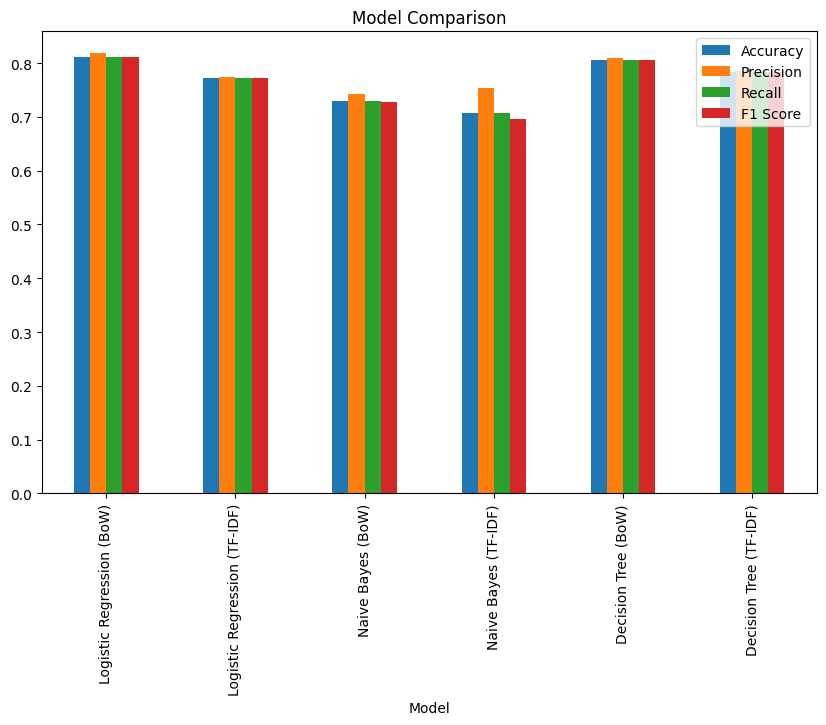

In [55]:
# Visualize comparison
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(10,6), title='Model Comparison')

## 6. Comparison & Insights
- Best preprocessing steps, vectorization, model, and trade-offs discussed below.

### Summary of Findings
- **Best Preprocessing:** Lemmatization generally preserves word meaning better than stemming.
- **Best Vectorization:** TF-IDF often outperforms BoW by considering word importance.
- **Best Model:** Logistic Regression and Naive Bayes usually perform well for text classification; Decision Tree may overfit.
- **Trade-offs:** Simpler models are faster but may miss complex patterns. More complex models may require more data and tuning.
- **Recommendation:** Use clean preprocessing, TF-IDF, and start with Logistic Regression or Naive Bayes for baseline.